Импорт необходимых модулей:

In [13]:
import imp
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import numpy as np
from PIL import Image 

from cmath import isclose
import math

import multiprocessing
from joblib import Parallel, delayed
# from math import isqrt

import platform
import subprocess

### Генерируем точки + строим графики и изображения

In [14]:
#total_points_sqrt = 3163
total_points_sqrt = 3163
total_points = total_points_sqrt * total_points_sqrt

print(total_points)

10004569


Билдим проект через cmake

In [15]:
subprocess.run(['cmake', '--build', 'bin/', '--target', 'clean'])
subprocess.run(['cmake', '.', '-B', 'bin/', '-G', 'Ninja', '-D', 'CMAKE_BUILD_TYPE=Release'])
subprocess.run(['cmake', '--build', 'bin/'])

[1/1] Cleaning all built files...
Cleaning... 6 files.
-- Configuring done
-- Generating done
-- Build files have been written to: /home/joel/Development/practice/nikulin/cpp/2_pi_monte_carlo/histogram/bin
[1/6] Building C object CMakeFiles/generators-JUPITER_NOTEBOOK.dir/generators.c.o
[2/6] Linking C static library libgenerators.a
[3/6] Building CXX object CMakeFiles/ResearchGenerators-JUPITER_NOTEBOOK.dir/main.cpp.o
[4/6] Building CXX object CMakeFiles/samples-JUPITER_NOTEBOOK.dir/samples.cpp.o
[5/6] Linking CXX static library libsamples.a
[6/6] Linking CXX executable ResearchGenerators


CompletedProcess(args=['cmake', '--build', 'bin/'], returncode=0)

Запускаем генерацию точек

In [16]:
if platform.system() == 'Windows':
    out = subprocess.check_output( ".\\bin\\ResearchGenerators.exe --xs64 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( ".\\bin\\ResearchGenerators.exe --xs1024 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( ".\\bin\\ResearchGenerators.exe --mt19937 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( ".\\bin\\ResearchGenerators.exe --rand " + str(total_points), shell=True, text=True )
    print(out)
else:
    out = subprocess.check_output( "./bin/ResearchGenerators --xs64 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/ResearchGenerators --xs1024 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/ResearchGenerators --mt19937 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/ResearchGenerators --rand " + str(total_points), shell=True, text=True )
    print(out)

Elapsed time for generator: "xs64"; Total values: 10004569	 --- 3524529 microseconds

Elapsed time for generator: "xs1024"; Total values: 10004569	 --- 3489911 microseconds

Elapsed time for generator: "mt19937"; Total values: 10004569	 --- 3520673 microseconds

Elapsed time for generator: "rand"; Total values: 10004569	 --- 3509759 microseconds



Подгружаем сгенерированные выборки:

In [17]:
x64      = pd.read_csv("xs64.csv")
x1024    = pd.read_csv("xs1024.csv")
mt19937  = pd.read_csv("mt19937.csv")
rand     = pd.read_csv("rand.csv")

Вывод первых 5-ти значий со сгенерированного файла:

In [18]:
x64.head()

,randoms
0,0.212468
1,0.809248
2,0.534433
3,0.275283
4,0.201536


Описательная статистика:

In [19]:
x64['randoms'].describe()

count    1.000457e+07
mean     4.999144e-01
std      2.886202e-01
min      1.640670e-07
25%      2.499890e-01
50%      4.998590e-01
75%      7.498590e-01
max      1.000000e+00
Name: randoms, dtype: float64

Строим гистограммы:

In [20]:
bins = 1000
bins_ranges = np.arange(start=0, stop=1, step=1 / bins)

In [21]:
hist_x64, bins_ranges = np.histogram(x64.to_numpy(), bins_ranges)
hist_x1024, bins_ranges = np.histogram(x1024.to_numpy(), bins_ranges)
hist_mt19937, bins_ranges = np.histogram(mt19937.to_numpy(), bins_ranges)
hist_rand, bins_ranges = np.histogram(rand.to_numpy(), bins_ranges)

(9704.0, 10365.0)

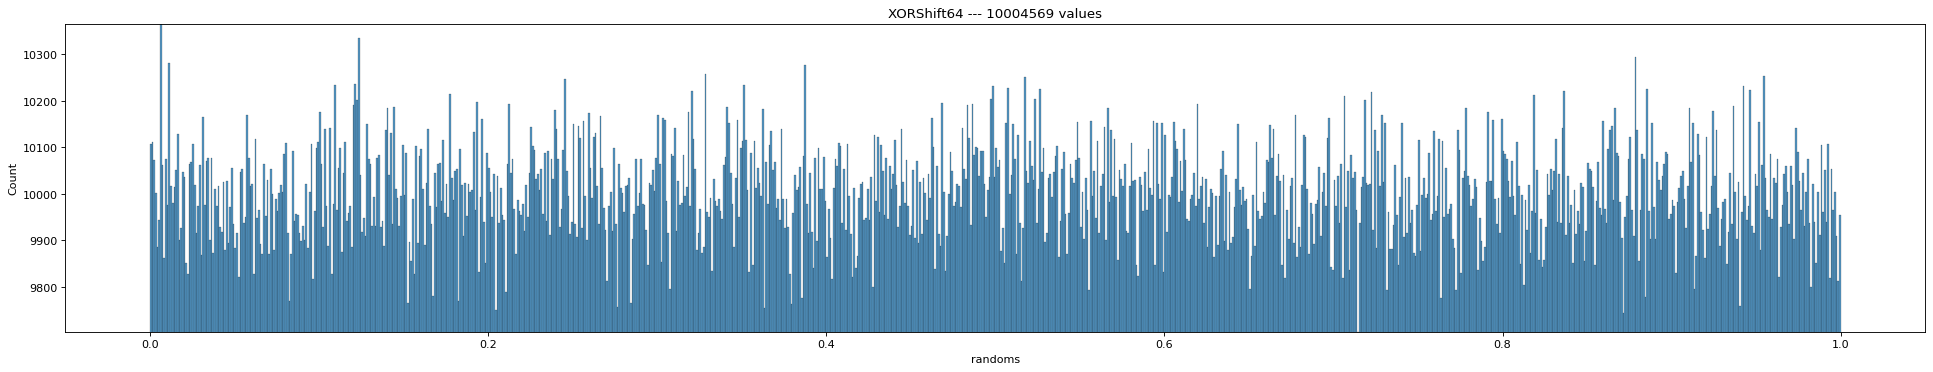

In [22]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x64, x="randoms", bins=bins).set(title='XORShift64 --- ' + str(total_points) + ' values')

plt.ylim(bottom=np.min(hist_x64), top=np.max(hist_x64))

In [23]:
data = 255 * np.array(x64)
data = np.uint8(data)

In [24]:
data.shape

(10004569, 1)

In [25]:
data = data.reshape(total_points_sqrt, total_points_sqrt)
print(data)

[[ 54 206 136 ...  42 204 128]
 [ 12 197 146 ... 237 188 178]
 [221   1 159 ... 201  51 224]
 ...
 [ 25 229 140 ...   2 213 155]
 [224   3  43 ... 122 150 155]
 [ 85  27 250 ... 137 247 249]]


In [26]:
data.shape

(3163, 3163)

In [27]:
img = Image.fromarray(data, 'L')
img.save('XORShift64_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9721.0, 10307.0)

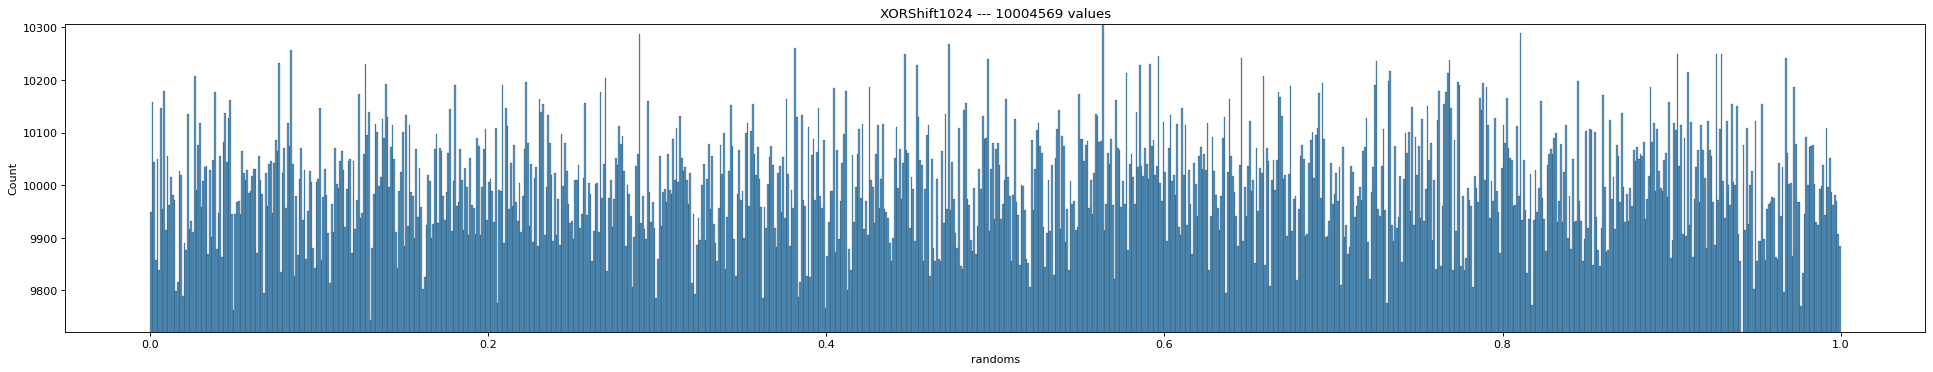

In [28]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x1024, x="randoms", bins=bins).set(title='XORShift1024 --- ' + str(total_points) + ' values')

plt.ylim(bottom=np.min(hist_x1024), top=np.max(hist_x1024))

In [29]:
data = 255 * np.array(x1024)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [30]:
img = Image.fromarray(data, 'L')
img.save('XORShift1024_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9670.0, 10385.0)

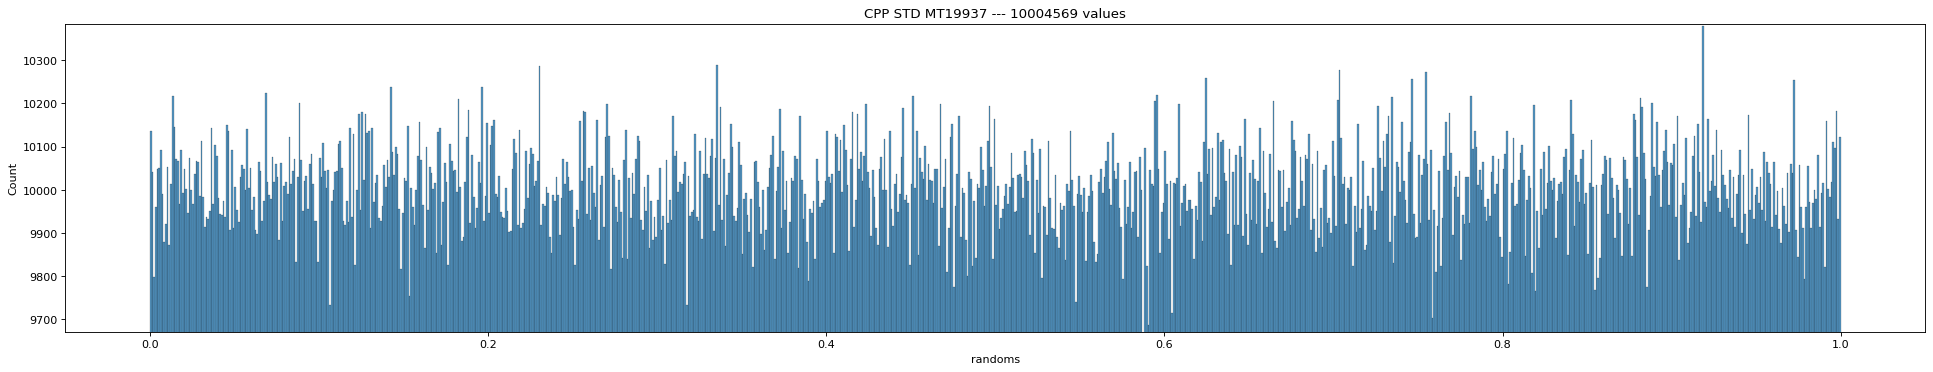

In [31]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=mt19937, x="randoms", bins=bins).set(title='CPP STD MT19937 --- ' + str(total_points) + ' values')

plt.ylim(bottom=np.min(hist_mt19937), top=np.max(hist_mt19937))

In [32]:
data = 255 * np.array(mt19937)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [33]:
img = Image.fromarray(data, 'L')
img.save('MT19937_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9666.0, 10312.0)

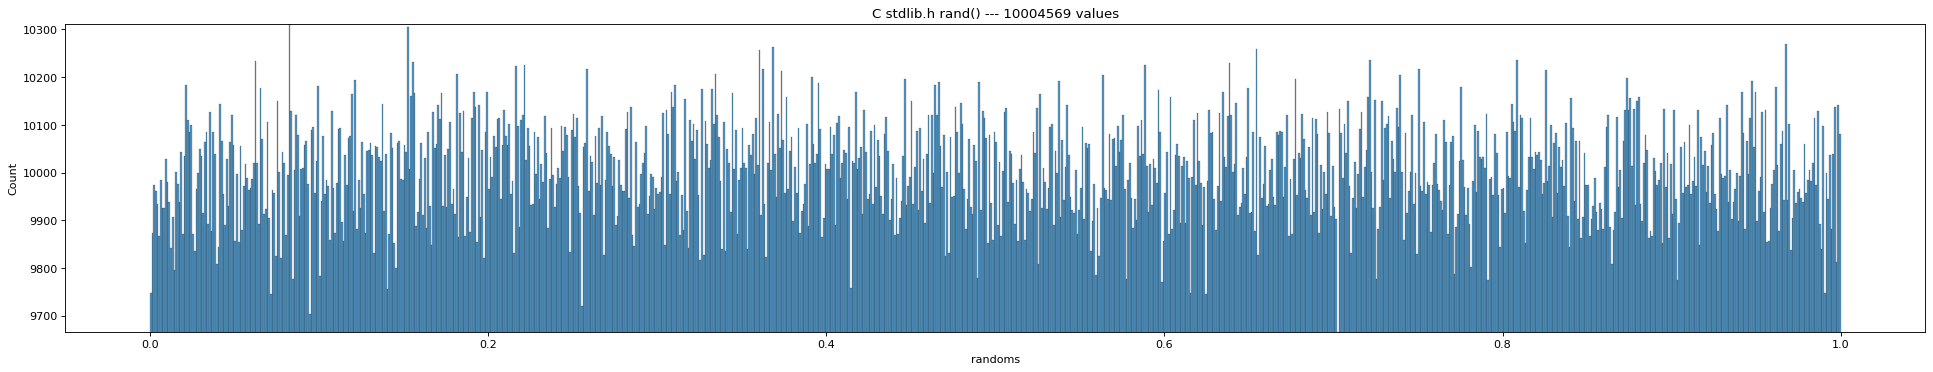

In [34]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=rand, x="randoms", bins=bins).set(title='C stdlib.h rand() --- ' + str(total_points) + ' values')

plt.ylim(bottom=np.min(hist_rand), top=np.max(hist_rand))

In [35]:
data = 255 * np.array(rand)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [36]:
img = Image.fromarray(data, 'L')
img.save('CSTDLibRand_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

## Метрики качества

In [37]:
# метод проверки, что хотя бы одно сгенерированное число из выборки есть в диапазоне [left..right), 
# ИДЕАЛЬНЫЙ ГЕНЕРАТОР выдаст ОДНО ЧИСЛО на ОДИН ДИАПАЗОН
def parallel_task(left, step, generated_values):
    right = left + step # next элемент (правый сосед, как граница диапазона) из массива expected_values

    for generated in generated_values:
        if (isclose(generated, left) or generated > left) and generated < right:
            # если сгенерированное число (generated) >= левой границе диапазона (left) и строго меньше правой границы (right) ---> выдать единицу
            return 1
                    
    return 0

# метод проверки качества сгенерированных значений, два типа проверки 'by-sum' -- быстрее и 'by-element' -- медленнее (но точнее)
def get_quality_of_values(generated_values, type='by-sum'):
    size = len(generated_values)

    # массив ожидаемых значений [0..1)
    range_step = 1.0 / size
    expected_values = np.arange(start=0, stop=1, step=range_step)    # ожидаемые значения ИДЕАЛЬНОГО ГЕНЕРАТОРА [0, 0.001, 0.002, ..., 1)

    generated_values = generated_values.to_numpy()
    error = None

    print(f'Expected values: {expected_values}')
    print(f'Generated values: {generated_values}')

    # проверка схожести суммы идеальных значений с суммой реальных значений
    # по сумме
    if type == 'by-sum':

        ideal_sum = expected_values.sum()
        real_sum = generated_values.sum()

        # отклонение от необходимой суммы в процентах
        error = abs( ideal_sum - real_sum ) 
        error /= ideal_sum

    # по элементно
    elif type == 'by-element':

        # parallel loop
        num_cores = multiprocessing.cpu_count()
        results = Parallel(n_jobs=num_cores)(delayed(parallel_task)(ideal, range_step, generated_values) for ideal in expected_values)

        # реальное количество диапазонов, в которых есть сгенерированные числа (В ИДЕАЛЕ, это число будет равно КОЛИЧЕСТВУ СГЕНЕРИРОВАННЫХ ЧИСЕЛ)
        good_elements = np.array(results).sum()

        error = 1 - good_elements / size
        print(f'Good elements: {good_elements}')
        print(f'Total generated values: {size}\nError: {error}')

    else:
        raise ValueError("Wrong type!")

    return 1 - error    # вывод качества с учётом ошибки ---> 1 - идеальный генератор, 0 - плохой генератор

Параметры для проверки качества:

In [38]:
#type = 'by-element'
type = 'by-sum'

Метрика качества для XorShift64:

In [39]:
quality = get_quality_of_values(x64, type)
print(f'XorShift64 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.212468]
 [0.809248]
 [0.534433]
 ...
 [0.537897]
 [0.969448]
 [0.979767]]
XorShift64 Quality: 0.9998289412455265


Метрика качества для XorShift1024:

In [40]:
quality = get_quality_of_values(x1024, type)
print(f'XorShift1024 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.650912]
 [0.7732  ]
 [0.827349]
 ...
 [0.590938]
 [0.55979 ]
 [0.758965]]
XorShift1024 Quality: 0.9997452111604616


Метрика качества для MT19937:

In [41]:
quality = get_quality_of_values(mt19937, type)
print(f'MT19937 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.65935 ]
 [0.654903]
 [0.508752]
 ...
 [0.82164 ]
 [0.571678]
 [0.832723]]
MT19937 Quality: 0.9998564000516013


In [42]:
quality = get_quality_of_values(rand, type)
print(f'C stdlib.h rand() Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.479503]
 [0.914811]
 [0.184333]
 ...
 [0.519029]
 [0.212272]
 [0.358541]]
C stdlib.h rand() Quality: 0.9999234619483532


### Среднеквадратичное отклонение

In [43]:
size = len(hist_x64)
avg = np.mean(hist_x64)
max = np.max(hist_x64)
min = np.min(hist_x64)

# print(len(bins))
# print(avg)
# print(size)

RMSD = 0
for h in hist_x64:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for XorShift64 = {NRMSD}')

Root mean square deviation for XorShift64 = 0.15125742308677118


In [44]:
size = len(hist_x1024)
avg = np.mean(hist_x1024)
max = np.max(hist_x1024)
min = np.min(hist_x1024)

RMSD = 0
for h in hist_x1024:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for XorShift1024 = {NRMSD}')

Root mean square deviation for XorShift1024 = 0.17163109307647187


In [45]:
size = len(hist_mt19937)
avg = np.mean(hist_mt19937)
max = np.max(hist_mt19937)
min = np.min(hist_mt19937)

RMSD = 0
for h in hist_mt19937:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for MT19937 = {NRMSD}')

Root mean square deviation for MT19937 = 0.1365992049398053


In [46]:
size = len(hist_rand)
avg = np.mean(hist_rand)
max = np.max(hist_rand)
min = np.min(hist_rand)

RMSD = 0
for h in hist_rand:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for rand() = {NRMSD}')

Root mean square deviation for rand() = 0.15629759120501588
